In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm    
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import calibration_curve
from scipy import stats

In [2]:
data_dir = '/home/rmhihbp/my_ukb_thesis/data'
target_col = 'def_CVD_AF_HF_AFTER'

continuous_cols = ['age_defined_baseline', 'BMI', 'sleep_hrs']  
binary_cols = ['genetic_sex', 'mental_doctor', 'uni_degree',
            'FH_cvd_f', 'FH_cvd_m', 'FH_cvd_sib',
            'smk_prev', 'smk_curr', 'alc_curr', 'PA_active']
final_features = continuous_cols + binary_cols

df_B = pd.read_parquet(os.path.join(data_dir, 'split_B_train.parquet')) 
df_C = pd.read_parquet(os.path.join(data_dir, 'split_C_test.parquet'))

X_B_raw, Y_B = df_B[final_features], df_B[target_col]
X_C_raw, Y_C = df_C[final_features], df_C[target_col]

In [3]:
# Single imputation using IterativeImputer
imputer = IterativeImputer(max_iter=10, random_state=42)
X_B_imp = pd.DataFrame(imputer.fit_transform(X_B_raw), columns=final_features, index=X_B_raw.index)
X_C_imp = pd.DataFrame(imputer.transform(X_C_raw), columns=final_features, index=X_C_raw.index)

for col in binary_cols: # round and clip binary features to ensure they remain 0 or 1 after imputation
    X_B_imp[col] = np.clip(np.round(X_B_imp[col]), 0, 1)
    X_C_imp[col] = np.clip(np.round(X_C_imp[col]), 0, 1)

In [4]:
print('\nMissing rate before imputation in Split B:')
missing_rates = X_B_raw.isnull().mean() * 100
missing_rates_filtered = missing_rates[missing_rates > 0].round(2)
if missing_rates_filtered.empty:
    print('There are no missing values in Split B before imputation.')
else:
    for feature, rate in missing_rates_filtered.items():
        print(f"{feature}: {rate}%")


Missing rate before imputation in Split B:
sleep_hrs: 0.61%
alc_curr: 0.31%


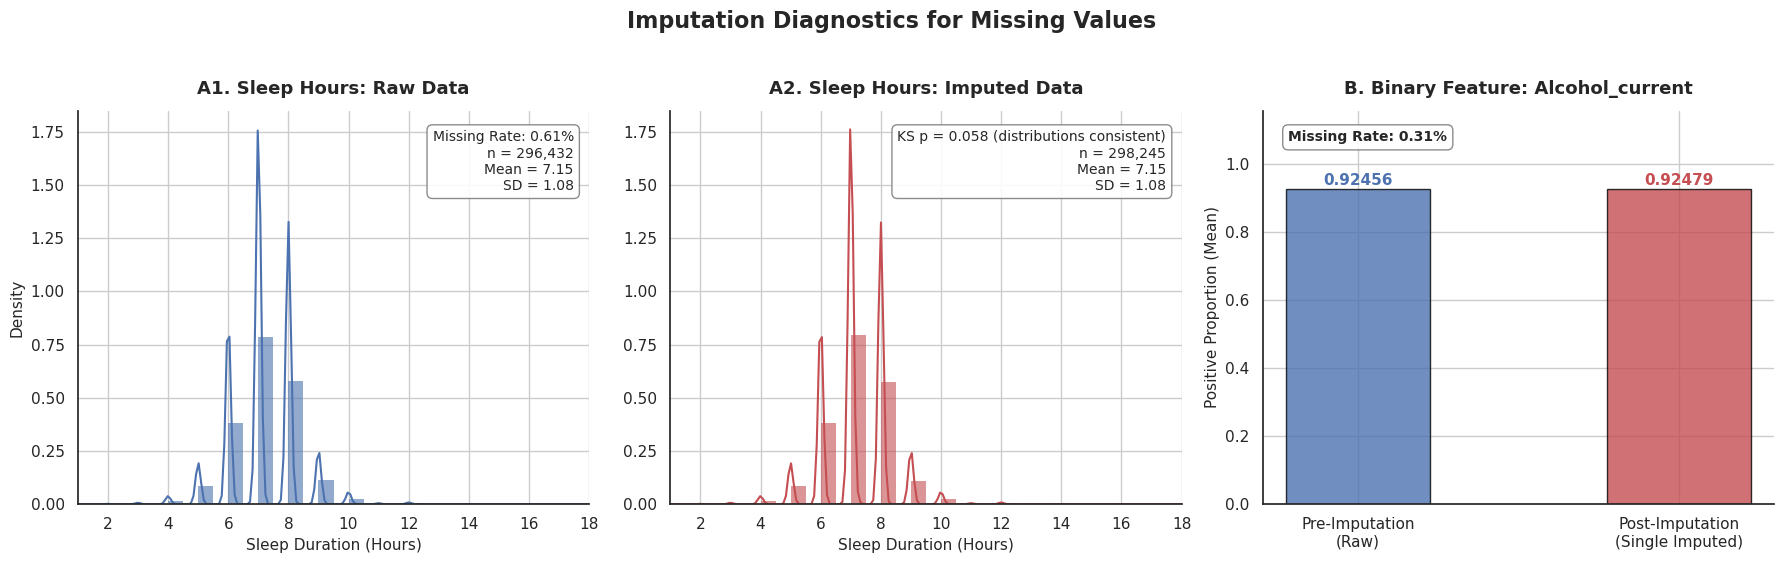

In [6]:
sns.set_theme(style="whitegrid", rc={"axes.edgecolor": "0.15", "axes.linewidth": 1.25})

# sleep(raw), sleep(imputed), alcohol_current(raw vs imputed)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5.5))

# continuous variable: sleep_hours (missing 0.61%)
raw_sleep = X_B_raw['sleep_hrs'].dropna()
imp_sleep = X_B_imp['sleep_hrs']

# range of x-axis for both raw and imputed data
x_min = min(raw_sleep.min(), imp_sleep.min())
x_max = max(raw_sleep.max(), imp_sleep.max())
bin_edges = np.arange(x_min, x_max + 0.5, 0.5) # bin width of 0.5 hours

# Plot A1：sleep hours raw data
sns.histplot(raw_sleep, color='#4C72B0', kde=True, stat="density",
            linewidth=0, alpha=0.6, ax=ax1, binrange=(x_min, x_max), bins=bin_edges)
ax1.set_title('A1. Sleep Hours: Raw Data', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Sleep Duration (Hours)', fontsize=11)
ax1.set_ylabel('Density', fontsize=11)
ax1.set_xlim(x_min, x_max)

# summary statistics for raw data
bbox_props = dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9)

legend_raw = (f"Missing Rate: {X_B_raw['sleep_hrs'].isna().mean():.2%}\n"
              f"n = {len(raw_sleep):,}\n"
              f"Mean = {raw_sleep.mean():.2f}\n"
              f"SD = {raw_sleep.std():.2f}")
ax1.text(0.97, 0.95, legend_raw, transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right', bbox=bbox_props)


# Plot A2：sleep hours imputed data
sns.histplot(imp_sleep, color='#C44E52', kde=True, stat="density",
            linewidth=0, alpha=0.6, ax=ax2, binrange=(x_min, x_max), bins=bin_edges)
ax2.set_title('A2. Sleep Hours: Imputed Data', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Sleep Duration (Hours)', fontsize=11)
ax2.set_ylabel('')
ax2.set_xlim(x_min, x_max)

# KS test
ks_stat, ks_p = stats.ks_2samp(raw_sleep, imp_sleep)
# summary statistics for imputed data
legend_imp = (f"KS p = {ks_p:.3f} (distributions consistent)\n"
              f"n = {len(imp_sleep):,}\n"
              f"Mean = {imp_sleep.mean():.2f}\n"
              f"SD = {imp_sleep.std():.2f}")
ax2.text(0.97, 0.95, legend_imp, transform=ax2.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right', bbox=bbox_props)

# synchronize y-axis limits for raw and imputed sleep hours
ax1.sharey(ax2)
y_max = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
ax1.set_ylim(0, y_max)
ax2.set_ylim(0, y_max)

# Plot B：Binary variable
raw_alc = X_B_raw['alc_curr'].dropna().mean()
imp_alc = X_B_imp['alc_curr'].mean()

bars = ax3.bar(['Pre-Imputation\n(Raw)', 'Post-Imputation\n(Single Imputed)'],
            [raw_alc, imp_alc],
            color=['#4C72B0', '#C44E52'],
            alpha=0.8, width=0.45, edgecolor='black', linewidth=1)

ax3.set_title('B. Binary Feature: Alcohol_current', fontsize=13, fontweight='bold', pad=12)
ax3.set_ylabel('Positive Proportion (Mean)', fontsize=11)
ax3.set_ylim(0, max(raw_alc, imp_alc) * 1.25)

ax3.text(0, raw_alc + 0.005, f'{raw_alc:.5f}', ha='center', va='bottom',
        fontsize=11, fontweight='bold', color='#4C72B0')
ax3.text(1, imp_alc + 0.005, f'{imp_alc:.5f}', ha='center', va='bottom',
        fontsize=11, fontweight='bold', color='#C44E52')
ax3.text(0.05, 0.95, f"Missing Rate: {X_B_raw['alc_curr'].isna().mean():.2%}",
        transform=ax3.transAxes, fontsize=10, fontweight='bold',
        verticalalignment='top', bbox=bbox_props)

sns.despine(ax=ax1)
sns.despine(ax=ax2)
sns.despine(ax=ax3)

plt.suptitle('Imputation Diagnostics for Missing Values', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

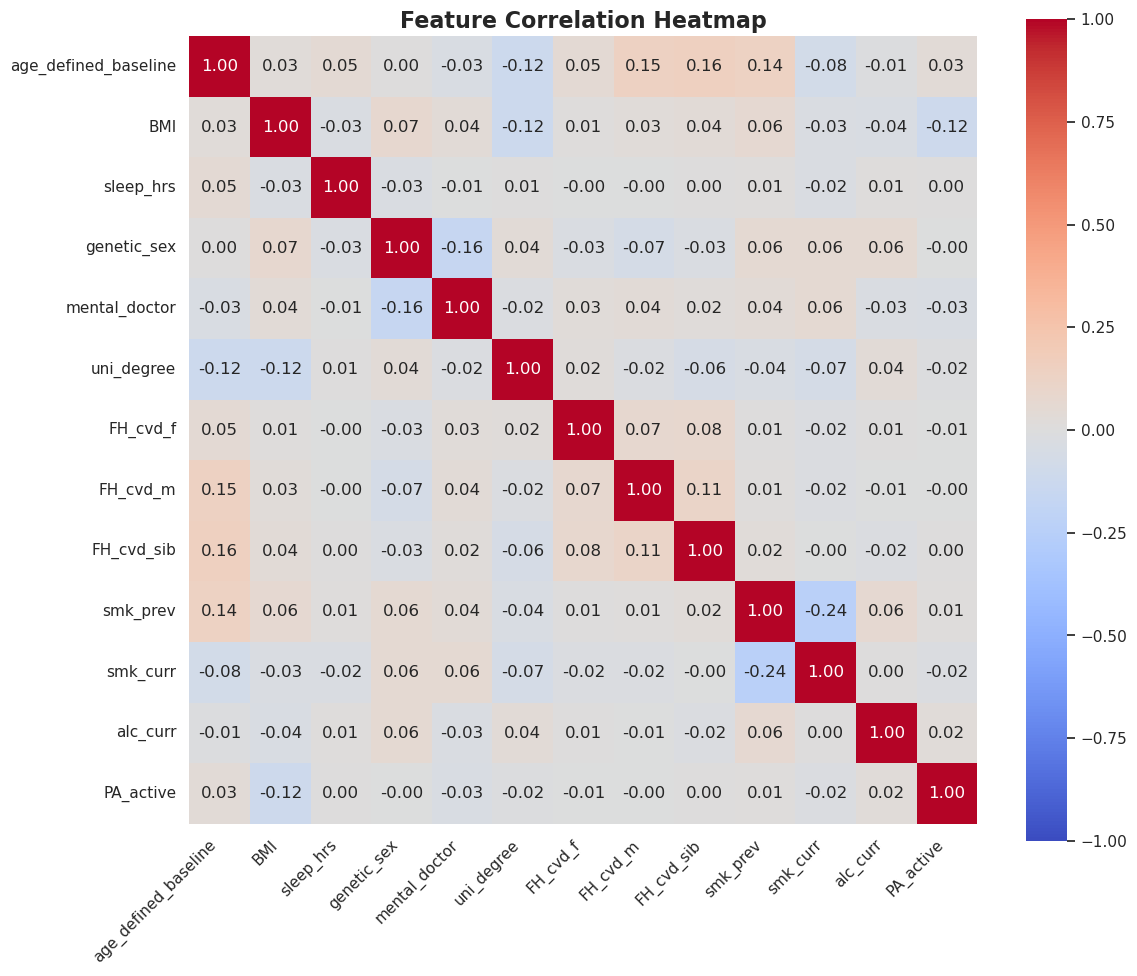

In [7]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
corr_matrix = X_B_imp.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True )
plt.title('Feature Correlation Heatmap',fontsize=16, fontweight='bold')
plt.xticks(rotation=45, horizontalalignment='right')
plt.tight_layout()
plt.show()

In [8]:
# Univariate association
print("\nUnivariate Association with Target Variable (CVD_AF_HF_AFTER):")
assoc_df = X_B_imp.copy()
assoc_df['CVD_Outcome'] = Y_B.values
mean_comparison = assoc_df.groupby('CVD_Outcome').mean().T.round(3)
mean_comparison.columns = ['No CVD (0)', 'CVD (1)']
mean_comparison['Absolute Diff'] = abs(mean_comparison['CVD (1)'] - mean_comparison['No CVD (0)'])
print(f"{mean_comparison.sort_values(by='Absolute Diff', ascending=False)}")


Univariate Association with Target Variable (CVD_AF_HF_AFTER):
                      No CVD (0)  CVD (1)  Absolute Diff
age_defined_baseline      55.773   60.716          4.943
BMI                       27.082   28.346          1.264
genetic_sex                0.421    0.595          0.174
uni_degree                 0.341    0.260          0.081
FH_cvd_m                   0.272    0.352          0.080
FH_cvd_sib                 0.116    0.186          0.070
smk_prev                   0.330    0.399          0.069
FH_cvd_f                   0.378    0.428          0.050
smk_curr                   0.100    0.140          0.040
alc_curr                   0.926    0.907          0.019
mental_doctor              0.337    0.356          0.019
PA_active                  0.820    0.802          0.018
sleep_hrs                  7.147    7.152          0.005


In [9]:
# Standardize continuous features
scaler = StandardScaler()
X_B_final = X_B_imp.copy()
X_C_final = X_C_imp.copy()
X_B_final[continuous_cols] = scaler.fit_transform(X_B_imp[continuous_cols])
X_C_final[continuous_cols] = scaler.transform(X_C_imp[continuous_cols])

In [10]:
# Logistic Regression
X_B_sm = sm.add_constant(X_B_final) # add intercept term for statsmodels
X_C_sm = sm.add_constant(X_C_final)

logit_model = sm.Logit(Y_B, X_B_sm).fit(disp=False) # fit logistic regression model on training data
print(logit_model.summary())

print('\n=== (Odds Ratios) ===')
conf = logit_model.conf_int()
conf['OR'] = logit_model.params
conf.columns = ['2.5% CI', '97.5% CI', 'Odds Ratio'] # calculate confidence intervals and odds ratios

result_table = np.exp(conf)
result_table['P-value'] = logit_model.pvalues # add p-values to the result table
print(result_table.sort_values(by='P-value', ascending=True))

                            Logit Regression Results                           
Dep. Variable:     def_CVD_AF_HF_AFTER   No. Observations:               298245
Model:                           Logit   Df Residuals:                   298231
Method:                            MLE   Df Model:                           13
Date:                 Thu, 16 Apr 2026   Pseudo R-squ.:                 0.09124
Time:                         14:40:50   Log-Likelihood:                -80674.
converged:                        True   LL-Null:                       -88774.
Covariance Type:             nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -2.9369      0.030    -98.941      0.000      -2.995      -2.879
age_defined_baseline     0.7021      0.008     85.239      0.000       0.686       0.718
BMI 

In [11]:
y_train_prob = logit_model.predict(X_B_sm) # predict probabilities on training data
y_test_prob = logit_model.predict(X_C_sm) # predict probabilities on test data

def calculate_auc_ci(y_true, y_pred_prob, n_bootstraps=1000, alpha=0.95): # bootstrap method to calculate confidence intervals for AUC
    bootstrapped_scores = []
    rng = np.random.RandomState(42)
    indices = np.arange(len(y_true))
    for i in range(n_bootstraps):
        boot_indices = rng.choice(indices, size=len(indices), replace=True)
        if len(np.unique(y_true.iloc[boot_indices])) < 2:
            continue
        score = roc_auc_score(y_true.iloc[boot_indices], y_pred_prob.iloc[boot_indices])
        bootstrapped_scores.append(score)
    sorted_scores = np.array(bootstrapped_scores)
    sorted_scores.sort()
    lower = sorted_scores[int((1.0 - alpha) / 2.0 * len(sorted_scores))]
    upper = sorted_scores[int((1.0 + alpha) / 2.0 * len(sorted_scores))]
    return roc_auc_score(y_true, y_pred_prob), lower, upper

train_auc_logit, train_ci_lower, train_ci_upper = calculate_auc_ci(Y_B, y_train_prob)
test_auc_logit, test_ci_lower, test_ci_upper = calculate_auc_ci(Y_C, y_test_prob)
print(f'Logistic Regression AUC (Train, Split B): {train_auc_logit:.4f} (95% CI: {train_ci_lower:.4f} - {train_ci_upper:.4f})')
print(f'Logistic Regression AUC (Test, Split C): {test_auc_logit:.4f} (95% CI: {test_ci_lower:.4f} - {test_ci_upper:.4f})')

Logistic Regression AUC (Train, Split B): 0.7285 (95% CI: 0.7253 - 0.7321)
Logistic Regression AUC (Test, Split C): 0.7271 (95% CI: 0.7228 - 0.7314)


In [12]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced', n_jobs=-1)
rf_model.fit(X_B_final, Y_B) # fit random forest model on training data
y_pred_prob_rf = rf_model.predict_proba(X_C_final)[:, 1] # predict probabilities on test data

auc_rf = roc_auc_score(Y_C, y_pred_prob_rf)
print(f'Random Forest AUC (Test, Split C): {auc_rf:.4f}')

Random Forest AUC (Test, Split C): 0.7225


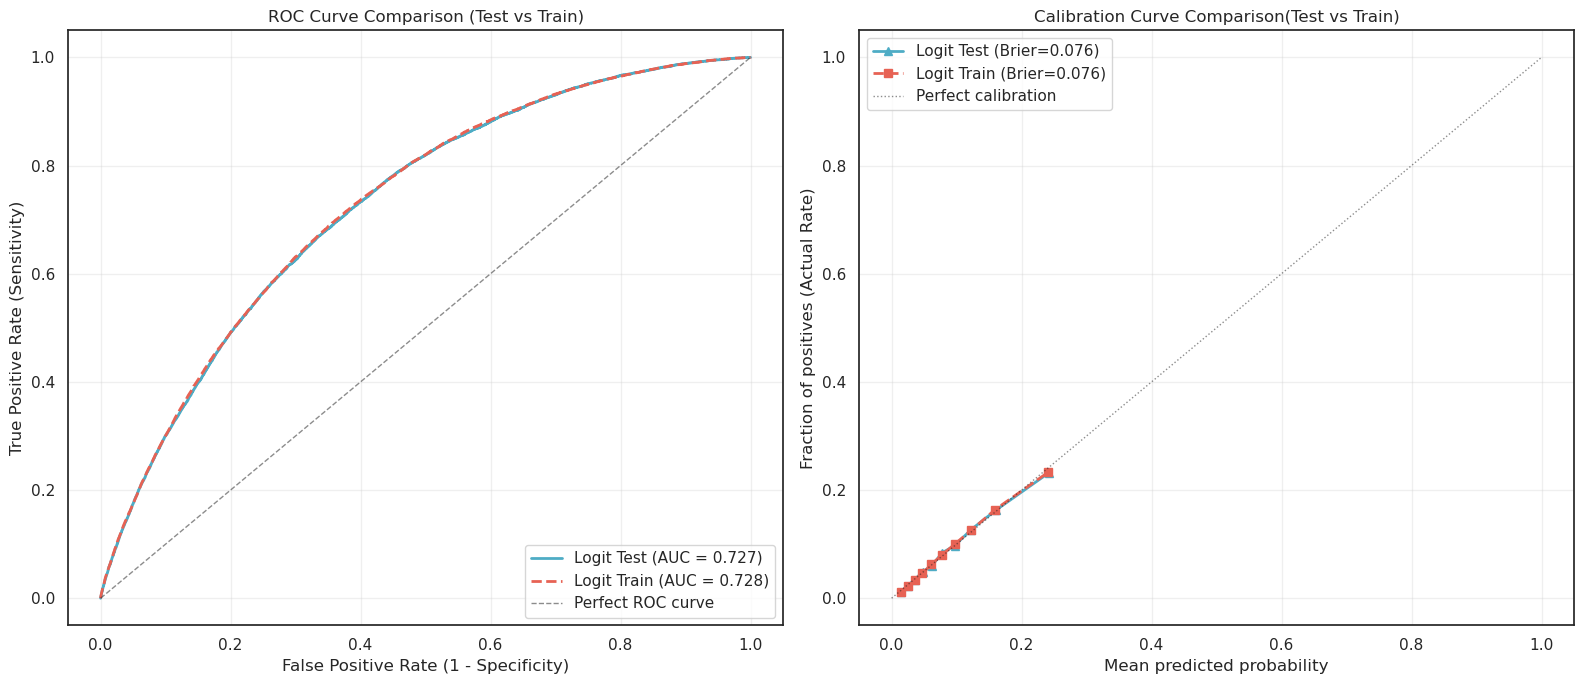

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Roc curve: Logistic Regression (Test set vs )
fpr_test, tpr_test, _ = roc_curve(Y_C, y_test_prob)
fpr_train, tpr_train, _ = roc_curve(Y_B, y_train_prob)

ax1.plot(fpr_test, tpr_test, label=f'Logit Test (AUC = {test_auc_logit:.3f})', color='#4EACC5', lw=2)
ax1.plot(fpr_train, tpr_train, label=f'Logit Train (AUC = {train_auc_logit:.3f})', color='#E76254', lw=2, linestyle='--')

ax1.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect ROC curve', alpha=0.5)
ax1.set_xlabel('False Positive Rate (1 - Specificity)')
ax1.set_ylabel('True Positive Rate (Sensitivity)')
ax1.set_title('ROC Curve Comparison (Test vs Train)')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)


# Calibration curve: Logistic Regression (Test set vs Train set)
frac_pos_test, mean_pred_test = calibration_curve(Y_C, y_test_prob, n_bins=10, strategy='quantile')
frac_pos_train, mean_pred_train = calibration_curve(Y_B, y_train_prob, n_bins=10, strategy='quantile')

ax2.plot(mean_pred_test, frac_pos_test, '^-', label=f'Logit Test (Brier={brier_score_loss(Y_C, y_test_prob):.3f})', color='#4EACC5', lw=2)
ax2.plot(mean_pred_train, frac_pos_train, 's--', label=f'Logit Train (Brier={brier_score_loss(Y_B, y_train_prob):.3f})', color='#E76254', lw=2)

ax2.plot([0, 1], [0, 1], 'k:', lw=1, label='Perfect calibration', alpha=0.5)
ax2.set_xlabel('Mean predicted probability')
ax2.set_ylabel('Fraction of positives (Actual Rate)')
ax2.set_title('Calibration Curve Comparison(Test vs Train)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

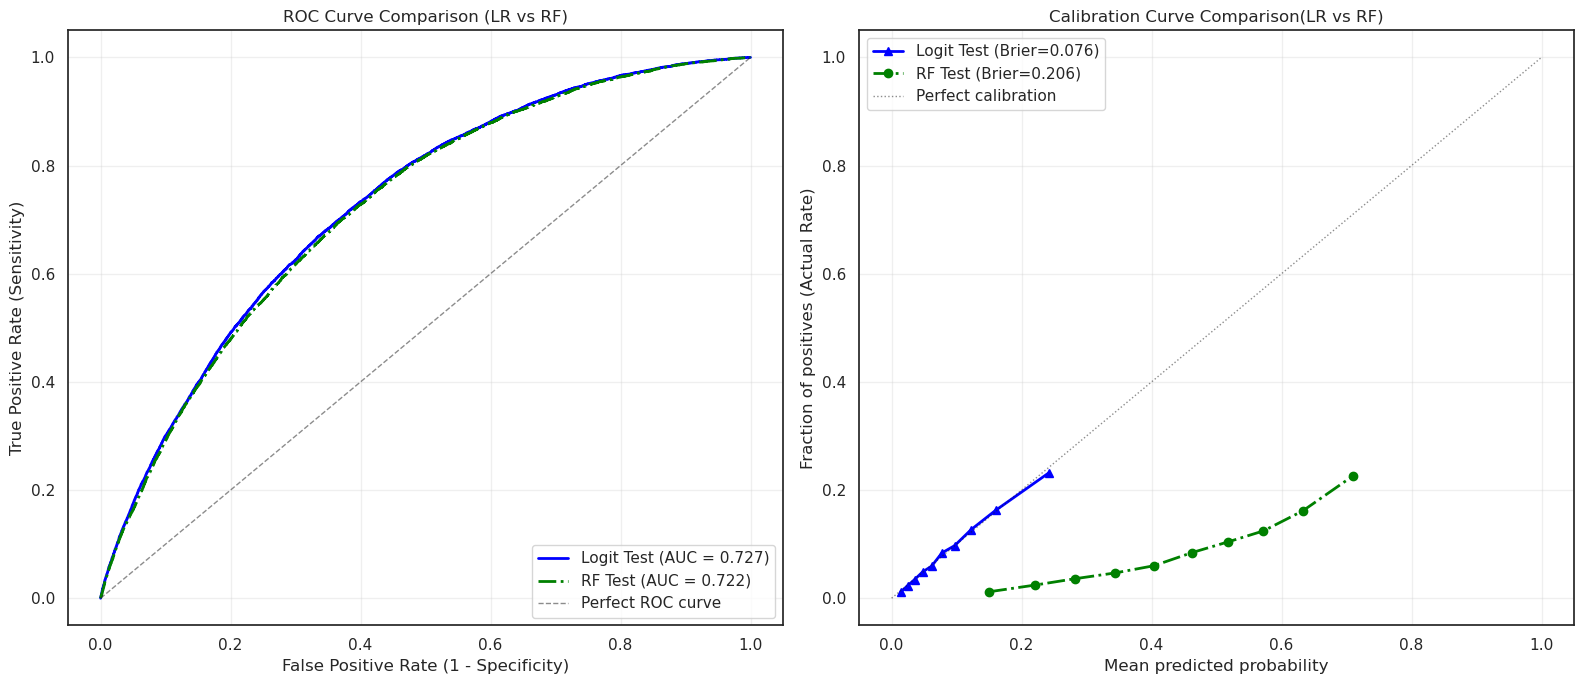

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Roc curve: Logistic Regression vs Random Forest
fpr_test, tpr_test, _ = roc_curve(Y_C, y_test_prob)
fpr_rf_test, tpr_rf_test, _ = roc_curve(Y_C, y_pred_prob_rf)

ax1.plot(fpr_test, tpr_test, label=f'Logit Test (AUC = {test_auc_logit:.3f})', color='blue', lw=2)
ax1.plot(fpr_rf_test, tpr_rf_test, label=f'RF Test (AUC = {auc_rf:.3f})', color='green', lw=2, linestyle='-.')

ax1.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect ROC curve', alpha=0.5)
ax1.set_xlabel('False Positive Rate (1 - Specificity)')
ax1.set_ylabel('True Positive Rate (Sensitivity)')
ax1.set_title('ROC Curve Comparison (LR vs RF)')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)


# Calibration curve: Logistic Regression vs Random Forest
frac_pos_test, mean_pred_test = calibration_curve(Y_C, y_test_prob, n_bins=10, strategy='quantile')
frac_pos_rf, mean_pred_rf = calibration_curve(Y_C, y_pred_prob_rf, n_bins=10, strategy='quantile')

ax2.plot(mean_pred_test, frac_pos_test, '^-', label=f'Logit Test (Brier={brier_score_loss(Y_C, y_test_prob):.3f})', color='blue', lw=2)
ax2.plot(mean_pred_rf, frac_pos_rf, 'o-.', label=f'RF Test (Brier={brier_score_loss(Y_C, y_pred_prob_rf):.3f})', color='green', lw=2)

ax2.plot([0, 1], [0, 1], 'k:', lw=1, label='Perfect calibration', alpha=0.5)
ax2.set_xlabel('Mean predicted probability')
ax2.set_ylabel('Fraction of positives (Actual Rate)')
ax2.set_title('Calibration Curve Comparison(LR vs RF)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

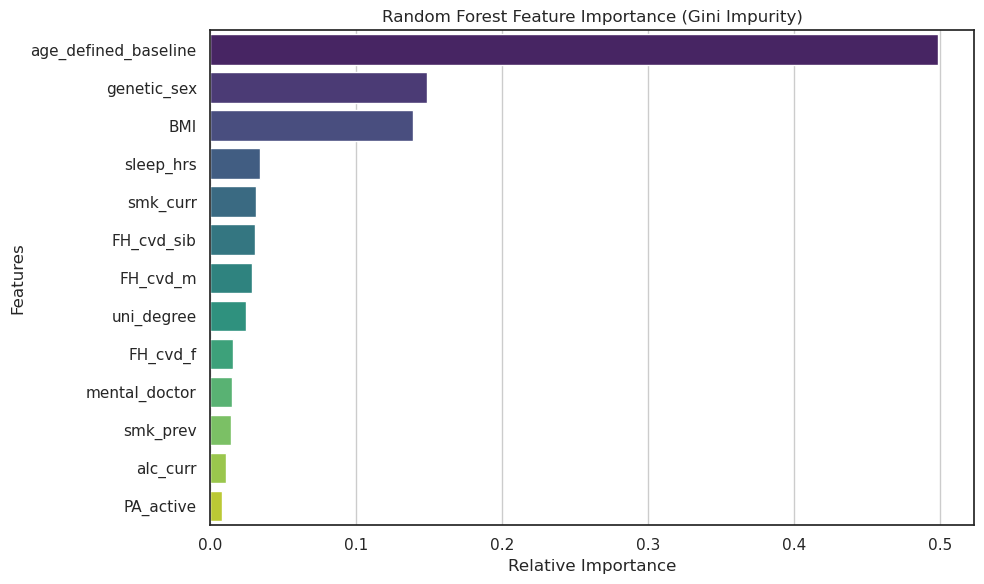

In [15]:
# supplementary figure: feature importance from random forest
rf_importances = rf_model.feature_importances_

rf_imp_df = pd.DataFrame({ 
    'Feature': final_features,
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=False) # create a DataFrame for feature importance and sort by importance

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=rf_imp_df, palette='viridis', legend=False)
plt.title('Random Forest Feature Importance (Gini Impurity)')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()